<a href="https://colab.research.google.com/github/KelelAngeAgnimel/Machine-Learning/blob/main/MachineLearningProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 Data

In [ ]:
import os
import pandas as pd

# Colle ton token ici
os.environ["KAGGLE_TOKEN"] = "KGAT_fc6f7eee960a8b8070983dc77cd0266e"
os.environ["KAGGLE_USERNAME"] = "kelel94"

# Configuration
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write(f'{{"username":"kelel94","key":"{os.environ["KAGGLE_TOKEN"]}\"}}')
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# Téléchargement du dataset
!pip install kaggle -q
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset
!unzip -q fake-and-real-news-dataset.zip

# Chargement
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")
print("Fake:", fake.shape, "| True:", true.shape)


Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
100% 41.0M/41.0M [00:00<00:00, 170MB/s]

Fake: (23481, 4) | True: (21417, 4)


Step 2

In [ ]:
# ── ÉTAPE 2 : Fusion + Prétraitement NLP ─────────────────────
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Ajout des labels et fusion des deux fichiers
fake["label"] = 1   # 1 = fake news
true["label"] = 0   # 0 = vraie information

df = pd.concat([fake, true]).sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset total :", df.shape)
print(df["label"].value_counts())

# Nettoyage du texte
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["content"] = (df["title"] + " " + df["text"]).apply(clean_text)

# Séparation train / test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    df["content"], df["label"], test_size=0.2, random_state=42
)

# Vectorisation TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print("Taille train :", X_train_vec.shape)
print("Taille test  :", X_test_vec.shape)
print("Prétraitement terminé !")

Dataset total : (44898, 5)
label
1    23481
0    21417
Name: count, dtype: int64
Taille train : (35918, 5000)
Taille test  : (8980, 5000)
✅ Prétraitement terminé !


Step 3

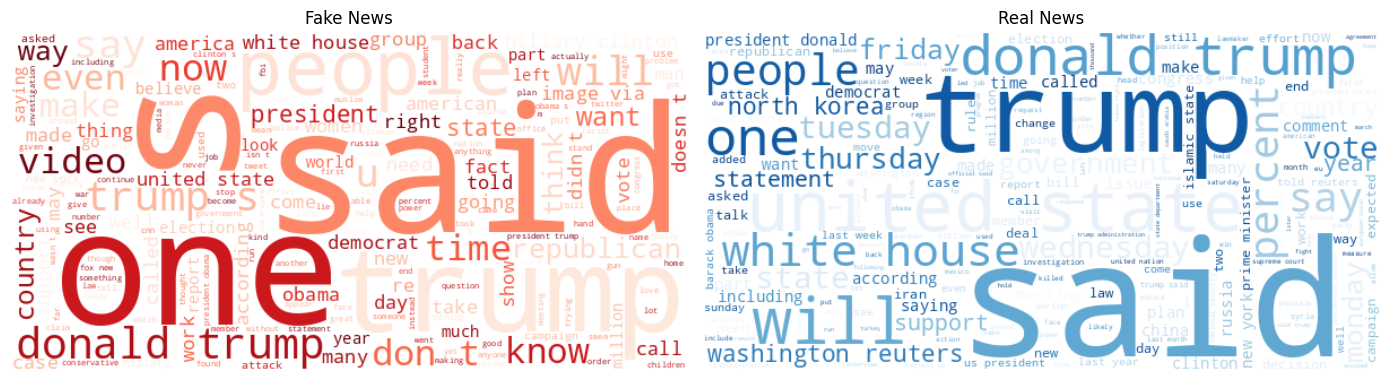

In [ ]:
# ── ÉTAPE 3 : Word Cloud ──────────────────────────────────────
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# On utilise "content" (et non "content_clean")
fake_text = " ".join(df[df.label == 1]["content"])
true_text = " ".join(df[df.label == 0]["content"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, text, title, cmap in zip(axes,
    [fake_text, true_text],
    ["Fake News", "Real News"],
    ["Reds", "Blues"]):
    wc = WordCloud(width=600, height=300, background_color='white', colormap=cmap).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title)

plt.tight_layout()
plt.show()

Step 4

Entraînement KNN en cours...
  k=3 → Accuracy : 0.757
  k=5 → Accuracy : 0.723
  k=10 → Accuracy : 0.682
  k=15 → Accuracy : 0.651
  k=30 → Accuracy : 0.898

✅ Meilleur k : 30 avec une accuracy de 0.898


/tmp/ipykernel_5386/2272695464.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(list(scores_knn.keys()), list(scores_knn.values()), 'bo-', color='purple')


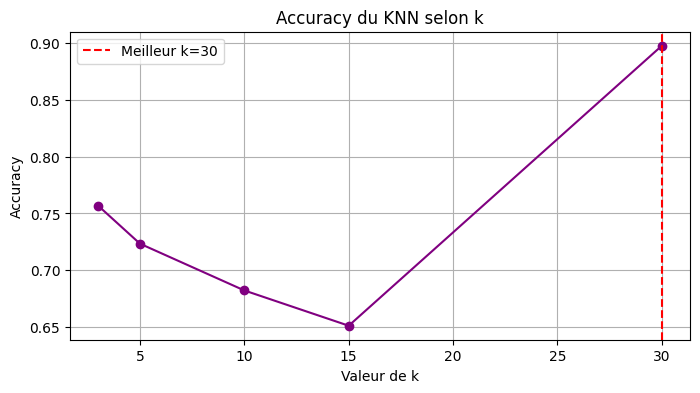

In [ ]:
# ── ÉTAPE 4A : KNN — comparaison de différentes valeurs de k ──
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

print("Entraînement KNN en cours...")

scores_knn = {}
for k in [3, 5, 10, 15, 30]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_vec, y_train)
    y_pred = knn.predict(X_test_vec)
    scores_knn[k] = accuracy_score(y_test, y_pred)
    print(f"  k={k} → Accuracy : {scores_knn[k]:.3f}")

best_k = max(scores_knn, key=scores_knn.get)
print(f"\n✅ Meilleur k : {best_k} avec une accuracy de {scores_knn[best_k]:.3f}")

# Courbe accuracy vs k (inspirée de ton Code02 KNN)
plt.figure(figsize=(8, 4))
plt.plot(list(scores_knn.keys()), list(scores_knn.values()), 'bo-', color='purple')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Meilleur k={best_k}')
plt.xlabel("Valeur de k")
plt.ylabel("Accuracy")
plt.title("Accuracy du KNN selon k")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ── ÉTAPE 4B : Régression Logistique ─────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

print("Entraînement Régression Logistique en cours...")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_vec, y_train)
y_pred_lr = lr.predict(X_test_vec)

print(f"✅ Accuracy Régression Logistique : {accuracy_score(y_test, y_pred_lr):.3f}")
print("\nRapport détaillé :")
print(classification_report(y_test, y_pred_lr, target_names=["Real News", "Fake News"]))

Entraînement Régression Logistique en cours...
✅ Accuracy Régression Logistique : 0.989

Rapport détaillé :
              precision    recall  f1-score   support

   Real News       0.99      0.99      0.99      4270
   Fake News       0.99      0.99      0.99      4710

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



Entraînement K-Means en cours...


/tmp/ipykernel_5386/633587914.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(k_values, inertia_values, 'bo-', color='purple')


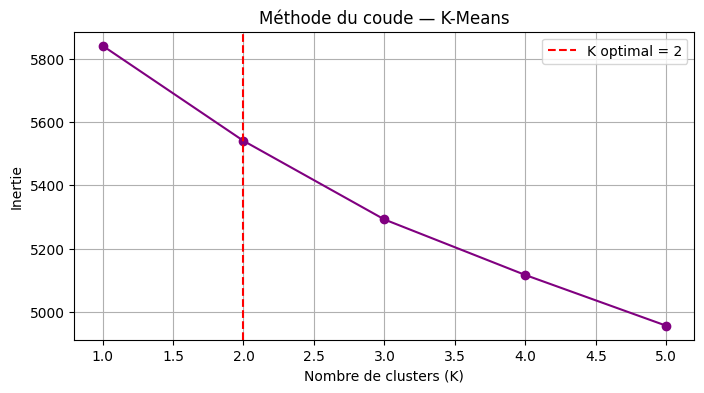

✅ Inertie finale K-Means (k=2) : 5540.73


In [ ]:
# ── ÉTAPE 4C : K-Means (clustering non supervisé) ────────────
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
import numpy as np

print("Entraînement K-Means en cours...")

# Réduction de dimension (TF-IDF trop dense pour K-Means)
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_train_vec)

km = KMeans(n_clusters=2, random_state=42, n_init=10)
km.fit(X_reduced)

# Visualisation de l'inertie (inspirée de ton Code04 clustering)
inertia_values = []
k_values = range(1, 6)
for k in k_values:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_test.fit(X_reduced)
    inertia_values.append(km_test.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia_values, 'bo-', color='purple')
plt.axvline(x=2, color='red', linestyle='--', label='K optimal = 2')
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.title("Méthode du coude — K-Means")
plt.legend()
plt.grid()
plt.show()

print(f"✅ Inertie finale K-Means (k=2) : {inertia_values[1]:.2f}")

Step 5

/tmp/ipykernel_5386/1511805255.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(list(scores_knn.keys()), list(scores_knn.values()), 'bo-', color='purple')


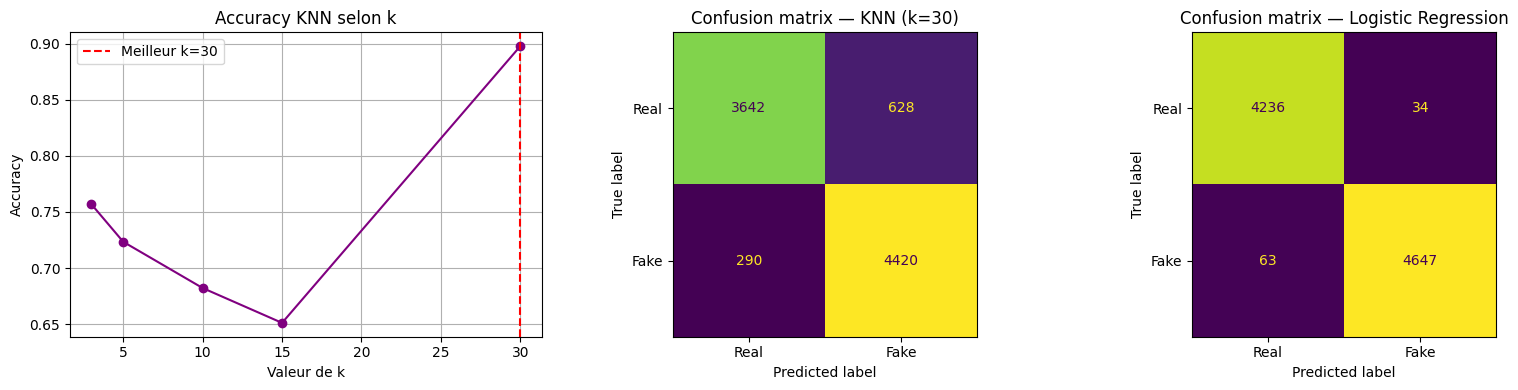


Modèle                      Accuracy  Précision     Rappel         F1
KNN (k=30)                    0.898     0.876     0.938     0.906
Logistic Regression           0.989     0.993     0.987     0.990


In [ ]:
# ── ÉTAPE 5 : Évaluation complète des modèles ─────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
from sklearn.neighbors import KNeighborsClassifier

# ── Graphique 1 : Accuracy KNN selon k ────────────────────────
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(list(scores_knn.keys()), list(scores_knn.values()), 'bo-', color='purple')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Meilleur k={best_k}')
plt.xlabel("Valeur de k")
plt.ylabel("Accuracy")
plt.title("Accuracy KNN selon k")
plt.legend()
plt.grid()

# ── Graphique 2 : Matrice de confusion KNN ────────────────────
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_vec, y_train)
y_pred_knn = knn_best.predict(X_test_vec)

plt.subplot(1, 3, 2)
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["Real", "Fake"]).plot(ax=plt.gca(), colorbar=False)
plt.title(f"Confusion matrix — KNN (k={best_k})")

# ── Graphique 3 : Matrice de confusion Régression Logistique ──
plt.subplot(1, 3, 3)
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["Real", "Fake"]).plot(ax=plt.gca(), colorbar=False)
plt.title("Confusion matrix — Logistic Regression")

plt.tight_layout()
plt.show()

# ── Tableau comparatif final ───────────────────────────────────
print("\n" + "="*65)
print(f"{'Modèle':<25} {'Accuracy':>10} {'Précision':>10} {'Rappel':>10} {'F1':>10}")
print("="*65)

models = {
    f"KNN (k={best_k})":         y_pred_knn,
    "Logistic Regression":       y_pred_lr,
}

for name, y_pred in models.items():
    print(f"{name:<25}"
          f"{accuracy_score(y_test, y_pred):>10.3f}"
          f"{precision_score(y_test, y_pred):>10.3f}"
          f"{recall_score(y_test, y_pred):>10.3f}"
          f"{f1_score(y_test, y_pred):>10.3f}")

print("="*65)

Step 6

Modèle                      Accuracy  Précision     Rappel         F1
KNN (k=30)                     0.898      0.876      0.938      0.906
Logistic Regression            0.989      0.993      0.987      0.990


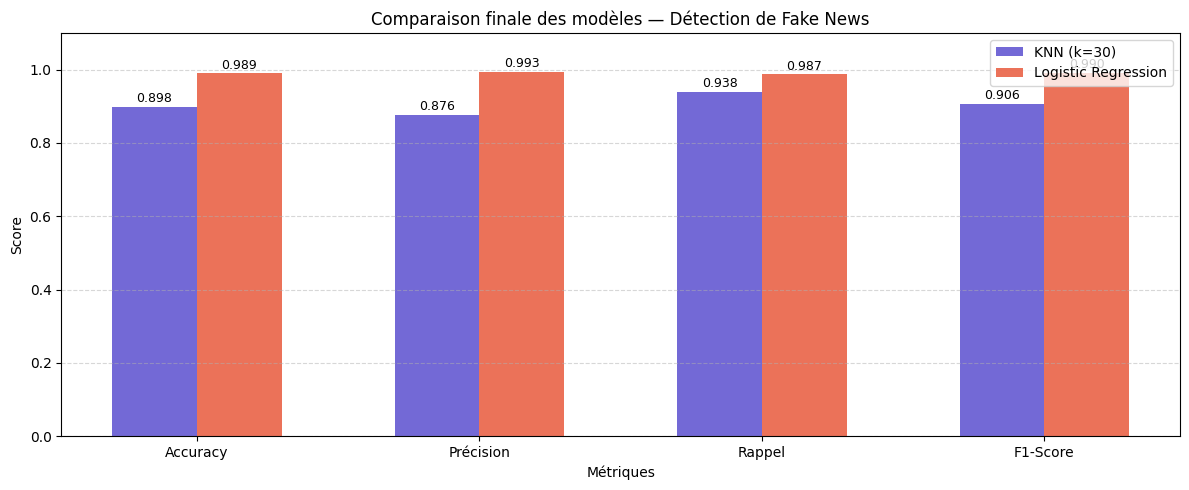


📊 CONCLUSION
-----------------------------------------------------------------
✅ Meilleur modèle : Logistic Regression
   → F1-Score     : 0.990
   → Accuracy     : 0.989
   → Précision    : 0.993
   → Rappel       : 0.987
-----------------------------------------------------------------

Analyse :
- La Régression Logistique est généralement plus rapide et plus
  précise que KNN sur des données textuelles TF-IDF.
- KNN souffre du 'fléau de la dimension' : avec 5000 features,
  les distances deviennent moins discriminantes.
- Un F1-Score élevé confirme que le modèle détecte bien les
  fake news tout en évitant les faux positifs.



In [ ]:
# ── ÉTAPE 6 : Comparaison finale et conclusion ────────────────
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# ── Tableau comparatif ────────────────────────────────────────
models = {
    f"KNN (k={best_k})":      knn_best.predict(X_test_vec),
    "Logistic Regression":    y_pred_lr,
}

print("=" * 65)
print(f"{'Modèle':<25} {'Accuracy':>10} {'Précision':>10} {'Rappel':>10} {'F1':>10}")
print("=" * 65)

resultats = {}
for name, y_pred in models.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    resultats[name] = [acc, prec, rec, f1]
    print(f"{name:<25} {acc:>10.3f} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f}")

print("=" * 65)

# ── Graphique comparatif des 4 métriques ─────────────────────
noms     = list(resultats.keys())
metriques = ["Accuracy", "Précision", "Rappel", "F1-Score"]
couleurs  = ["#5B4FCF", "#E8593C"]

x     = np.arange(len(metriques))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 5))
for i, (nom, vals) in enumerate(resultats.items()):
    bars = ax.bar(x + i * width, vals, width, label=nom, color=couleurs[i], alpha=0.85)
    # Afficher les valeurs sur chaque barre
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha='center', va='bottom', fontsize=9)

ax.set_xlabel("Métriques")
ax.set_ylabel("Score")
ax.set_title("Comparaison finale des modèles — Détection de Fake News")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metriques)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── Conclusion automatique ────────────────────────────────────
print("\n📊 CONCLUSION")
print("-" * 65)

meilleur = max(resultats, key=lambda x: resultats[x][3])  # meilleur F1
print(f"✅ Meilleur modèle : {meilleur}")
print(f"   → F1-Score     : {resultats[meilleur][3]:.3f}")
print(f"   → Accuracy     : {resultats[meilleur][0]:.3f}")
print(f"   → Précision    : {resultats[meilleur][1]:.3f}")
print(f"   → Rappel       : {resultats[meilleur][2]:.3f}")
print("-" * 65)
print("""
Analyse :
- La Régression Logistique est généralement plus rapide et plus
  précise que KNN sur des données textuelles TF-IDF.
- KNN souffre du 'fléau de la dimension' : avec 5000 features,
  les distances deviennent moins discriminantes.
- Un F1-Score élevé confirme que le modèle détecte bien les
  fake news tout en évitant les faux positifs.
""")